24
restraint strength: 22222.222222222223 kJ/(mol*nm^2)


/tmp/ipykernel_234005/744423489.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas("../run_c/1/COLVAR")
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++


(0.3, 0.6)

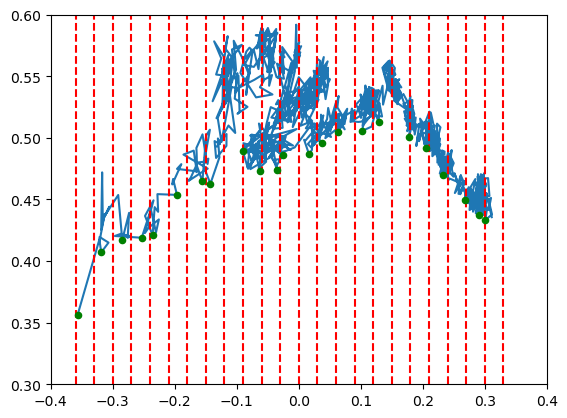

In [1]:
import plumed
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os       


colvar=plumed.read_as_pandas("../run_c/1/COLVAR")

#get regularly spaced points that are at least 0.03 nm apart in both dimensions
time = list(colvar.time)

delta = list(colvar.pc_f1b)
pc_c = list(colvar.pc_fc)
pc_m = list(colvar.pc_fm)

sigma = [i+j for i,j in zip(pc_c,pc_m)]

plt.plot(delta, sigma)

# coords = []
# times = []

# thresh = 0.03

# for t, (d,s) in enumerate(zip(delta, sigma)):
#     farenough = True
#     for c in coords:
#         if abs(d - c[0]) < thresh and abs(s - c[1]) < thresh:
#             farenough = False
#             break

#     if farenough or t == len(time)-1:
#         times.append(time[t])
#         #print(f"{time[t]} ps")
#         coords.append((d,s))

#         os.system(f"gmx trjconv -f mtd_seg_01.all.xtc -s ../mdp_hmr_4fs_01.tpr -o frame_{time[t]:.1f}ns.pdb -dump {time[t]:.1f}")

# print(f"found {len(coords)} points")
# plt.scatter([c[0] for c in coords], [c[1] for c in coords], color = "blue", s=2, zorder = 10000)

#define windows
winmin = -0.36
winmax = 0.36
winwidth = 0.03
nwindows = int((winmax - winmin)/winwidth)
binbounds = np.arange(winmin,winmax,winwidth)
print(nwindows)

#return restraint strength
#U=kx^2/2 => k=2U/x^2
energy_halfway_between_windows = 2.5  #kJ/mol
k_restraint = 2*energy_halfway_between_windows/(winwidth/2)**2
print(f"restraint strength: {k_restraint} kJ/(mol*nm^2)")

#find the frame in each window with the lowest sigma (i.e. the least unfolded one)
t_d_s_bywindow = []

for bbi in range(nwindows-1):
    #track the lowest sigma found so far for each window and the time at which it occurred
    t_d_s = []
    min_sigma = 999
    for t, d, s in zip(time, delta, sigma):
        #if the current frame is within the current window and has a lower sigma, update
        if d > binbounds[bbi] and d < binbounds[bbi+1] and s < min_sigma:
            t_d_s = [t, d, s]
            min_sigma = s
    if len(t_d_s) == 3:
        t_d_s_bywindow.append(t_d_s)

#get times of minimum-sigma frames for future extraction by trjconv
times = [t[0] for t in t_d_s_bywindow]

#save times for extraction on wynton, which has the trajectory files but not python plumed (I can't import it there)
np.save("window_init_frame_times.npy", times)

#plot window boundaries and selected points
for bb in binbounds:
    plt.axvline(x=bb, color='red', linestyle='--')
for bincenter in t_d_s_bywindow:
    #print(bincenter)
    plt.scatter(bincenter[1], bincenter[2], color = "green", s=20, zorder = 10000)

plt.xlim(-0.4, 0.4)
plt.ylim(0.3, 0.6)
